# Student Exam Score Prediction — Linear Regression
**Mission:** Identify the key behavioral and socioeconomic drivers of student academic performance to enable targeted early interventions in education systems.

**Dataset:** Student Performance Factors — 6,607 students, 20 features (Source: Kaggle / lainguyn123)

**Target Variable:** `Exam_Score` — continuous integer, range 55–101

| Feature Category | Examples |
|---|---|
| Behavioral | Hours Studied, Attendance, Sleep Hours |
| Socioeconomic | Family Income, Parental Education, Internet Access |
| Academic Support | Tutoring Sessions, Teacher Quality, School Type |

In [1]:
# === All Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Global plot style — consistent theme across all visualizations
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

## 1. Load & Explore Data

In [3]:
# Load the Student Performance Factors dataset
df = pd.read_csv('StudentPerformanceFactors.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74


In [4]:
# Clean dataset summary — dtype, missing count, and missing % per column
summary = pd.DataFrame({
    'Type':     df.dtypes.astype(str),
    'Missing':  df.isnull().sum(),
    'Missing%': (df.isnull().sum() / len(df) * 100).round(2)
})
summary.index.name = 'Column'
summary.style.background_gradient(subset=['Missing'], cmap='Reds')

,Type,Missing,Missing%
Column,,,
Hours_Studied,int64,0,0.000000
Attendance,int64,0,0.000000
Parental_Involvement,str,0,0.000000
Access_to_Resources,str,0,0.000000
Extracurricular_Activities,str,0,0.000000
Sleep_Hours,int64,0,0.000000
Previous_Scores,int64,0,0.000000
Motivation_Level,str,0,0.000000
Internet_Access,str,0,0.000000


Only 3 cols have missing values; Parental_Education_Level	90
Teacher_Quality	78
Distance_from_Home 67

## 2. Exploratory Data Analysis (EDA)

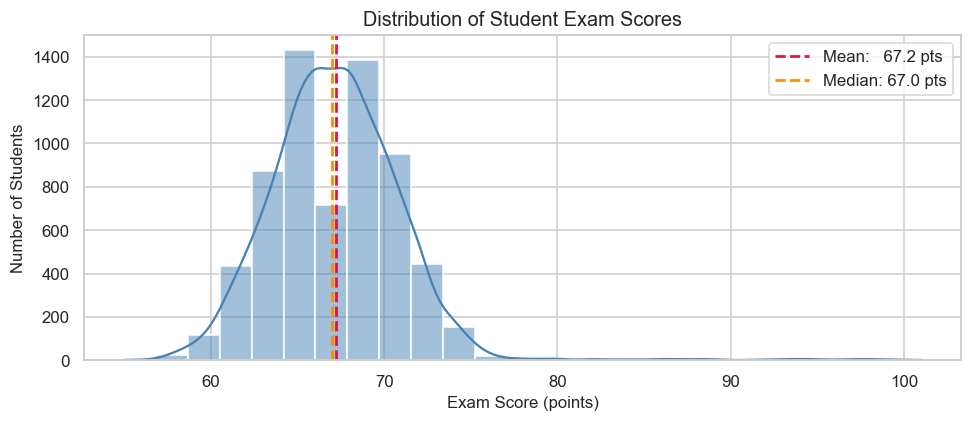

In [5]:
# Viz 1: Exam score distribution — mean/median lines, units on both axes
mean_s, med_s = df['Exam_Score'].mean(), df['Exam_Score'].median()
plt.figure(figsize=(9, 4))
sns.histplot(df['Exam_Score'], kde=True, bins=25, color='steelblue', edgecolor='white')
plt.axvline(mean_s, color='crimson',    ls='--', lw=1.8, label=f'Mean:   {mean_s:.1f} pts')
plt.axvline(med_s,  color='darkorange', ls='--', lw=1.8, label=f'Median: {med_s:.1f} pts')
plt.title('Distribution of Student Exam Scores')
plt.xlabel('Exam Score (points)'); plt.ylabel('Number of Students'); plt.legend()
plt.tight_layout(); plt.show()

**Interpretation — Viz 1:** The exam score distribution is approximately normal, centered at **67.2** (mean ≈ median → minimal skew). Most students score between 62–73. This tight, well-distributed target confirms `Exam_Score` is appropriate for regression — no log or Box-Cox transformation required.

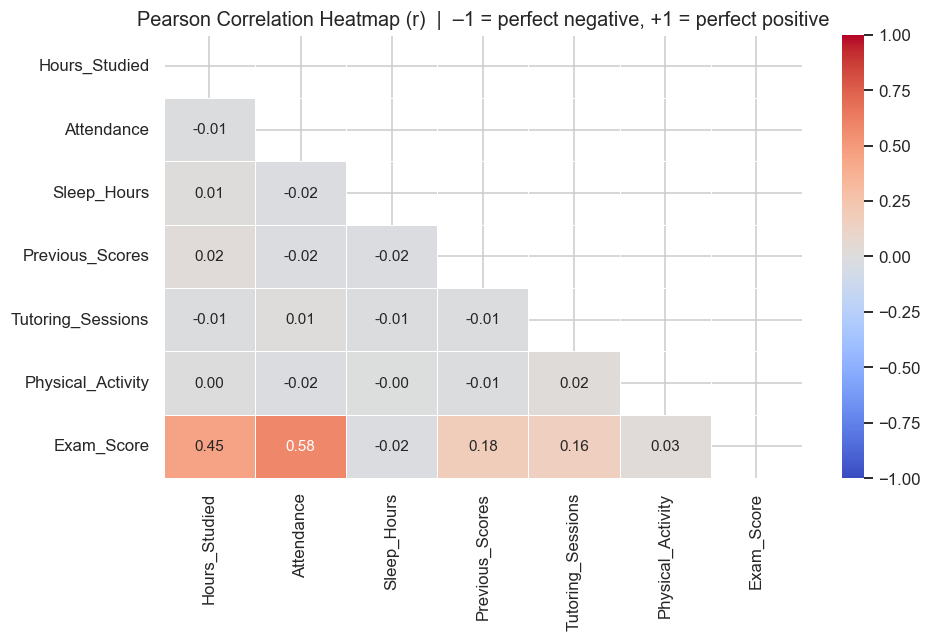

In [6]:
# Viz 2: Pearson correlation heatmap — lower triangle, r scale -1 to +1
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 10})
plt.title('Pearson Correlation Heatmap (r)  |  –1 = perfect negative, +1 = perfect positive')
plt.tight_layout(); plt.show()

**Interpretation — Viz 2:** `Attendance` (r=0.58) and `Hours_Studied` (r=0.45) are the strongest positive predictors of `Exam_Score`. `Previous_Scores` (r=0.18) and `Tutoring_Sessions` (r=0.16) show moderate correlation. `Sleep_Hours` (r=−0.02) and `Physical_Activity` (r=0.03) are near-zero — minimal direct linear impact. Features are not highly correlated with each other, so multicollinearity is not a concern.

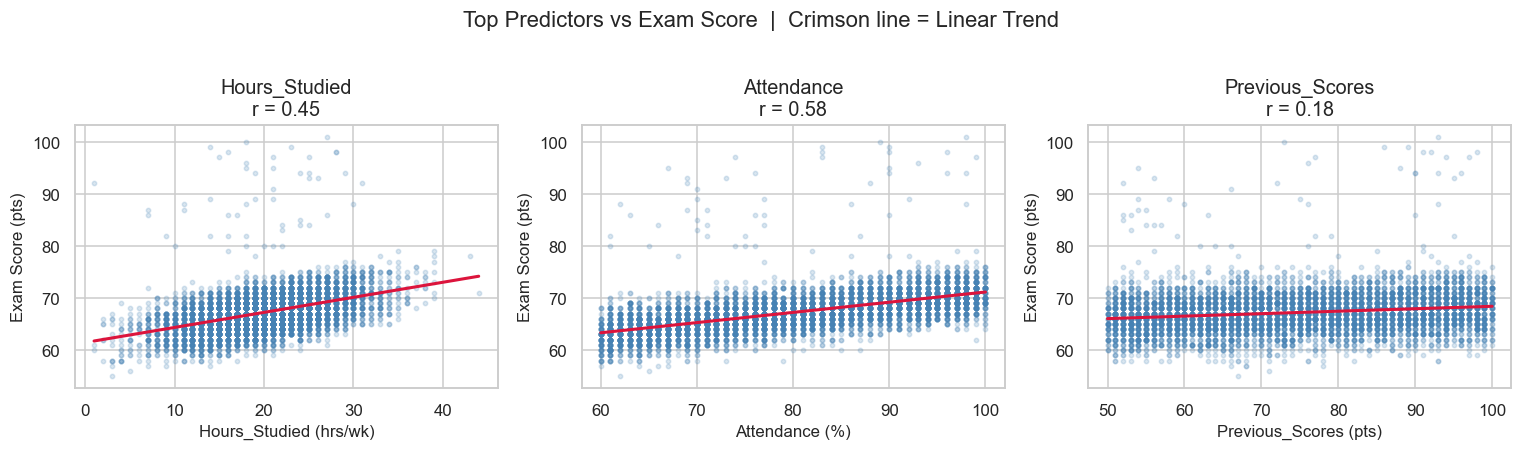

In [7]:
# Viz 3: Top predictors vs Exam Score — units, Pearson r, and trend lines
feats = [('Hours_Studied', 'hrs/wk'), ('Attendance', '%'), ('Previous_Scores', 'pts')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (f, u) in zip(axes, feats):
    x_s = np.sort(df[f].values); r = df[f].corr(df['Exam_Score'])
    ax.scatter(df[f], df['Exam_Score'], alpha=0.2, s=8, color='steelblue')
    ax.plot(x_s, np.polyval(np.polyfit(df[f], df['Exam_Score'], 1), x_s), color='crimson', lw=2)
    ax.set(xlabel=f'{f} ({u})', ylabel='Exam Score (pts)', title=f'{f}\nr = {r:.2f}')
plt.suptitle('Top Predictors vs Exam Score  |  Crimson line = Linear Trend', y=1.02)
plt.tight_layout(); plt.show()

**Interpretation — Viz 3:** All three features show a clear upward linear trend. `Attendance` has the steepest slope — consistent attendance strongly predicts higher scores. `Hours_Studied` shows a positive slope with moderate scatter, meaning study time matters but other factors also play a role. `Previous_Scores` has the tightest fit — prior academic performance is a strong, reliable predictor. All three are confirmed as high-priority features.

## 3. Preprocessing & Feature Engineering

In [8]:
# Impute 3 columns with missing values using column mode (most frequent category)
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])
print('Missing values remaining:', df.isnull().sum().sum())

Missing values remaining: 0


In [9]:
# Drop 'Gender' — near-zero correlation with Exam_Score (confirmed by heatmap)
# Retaining it adds noise without predictive value
df.drop(columns=['Gender'], inplace=True)
print('Features remaining:', df.shape[1] - 1, '(excluding target)')

Features remaining: 18 (excluding target)


In [10]:
# Label-encode all remaining categorical (string) columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print('Encoded columns:', cat_cols)

Encoded columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']


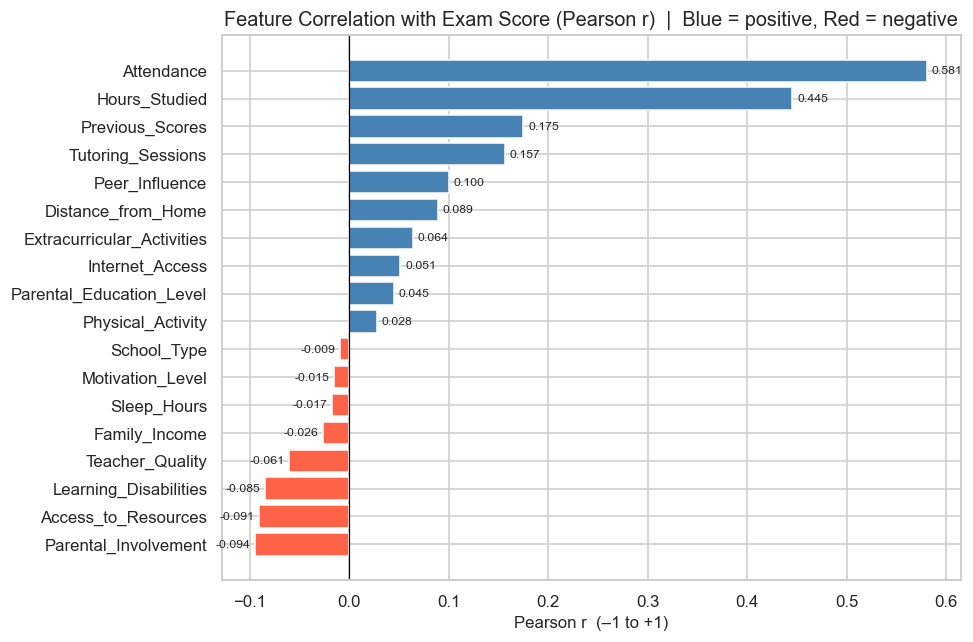

In [11]:
# Feature correlation bar chart — value-labelled, color-coded (blue=positive, red=negative)
corr_target = df.corr()['Exam_Score'].drop('Exam_Score').sort_values()
clrs = ['tomato' if v < 0 else 'steelblue' for v in corr_target]
plt.figure(figsize=(9, 6))
bars = plt.barh(corr_target.index, corr_target.values, color=clrs, edgecolor='white')
plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with Exam Score (Pearson r)  |  Blue = positive, Red = negative')
plt.xlabel('Pearson r  (–1 to +1)'); plt.tight_layout(); plt.show()

**Interpretation — Feature Correlation:** `Attendance`, `Hours_Studied`, and `Previous_Scores` are the strongest positive predictors (blue). `Learning_Disabilities` shows the strongest negative correlation — students with disabilities tend to score lower on average. `Distance_from_Home` also negatively impacts scores, likely due to commute fatigue. Features with near-zero correlation (e.g., `Sleep_Hours`, `Physical_Activity`) are retained — they may contribute non-linearly in tree-based models. `Gender` was dropped as it showed the weakest signal.

In [12]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']
print(f'Features: {X.shape[1]} | Target range: {y.min()}–{y.max()}')

Features: 18 | Target range: 55–101


In [13]:
# 80/20 train-test split — random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5285, 18) | Test: (1322, 18)


In [14]:
# Fit scaler on train set only — prevents data leakage into test set
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Standardized. Train mean ≈', round(X_train_sc.mean(), 4))

Standardized. Train mean ≈ -0.0


## 4. Model Training

In [15]:
# Initialize SGD Regressor — warm_start=True enables epoch-by-epoch tracking
sgd = SGDRegressor(
    max_iter=1, warm_start=True,
    eta0=0.01, learning_rate='constant', random_state=42
)
train_losses, test_losses = [], []

In [16]:
# Train for 300 epochs — record MSE after each pass through the data
for _ in range(300):
    sgd.fit(X_train_sc, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_sc)))
    test_losses.append(mean_squared_error(y_test,  sgd.predict(X_test_sc)))
lr_test_mse = test_losses[-1]
print(f'LR  → Train MSE: {train_losses[-1]:.4f} | Test MSE: {lr_test_mse:.4f}')

LR  → Train MSE: 5.6476 | Test MSE: 4.5522


In [17]:
# Compute predictions and extended metrics for linear regression
y_pred_lr = sgd.predict(X_test_sc)
lr_rmse   = np.sqrt(lr_test_mse)
lr_r2     = r2_score(y_test, y_pred_lr)
print(f'LR  → Test RMSE: {lr_rmse:.4f} | R2: {lr_r2:.4f}')

LR  → Test RMSE: 2.1336 | R2: 0.6779


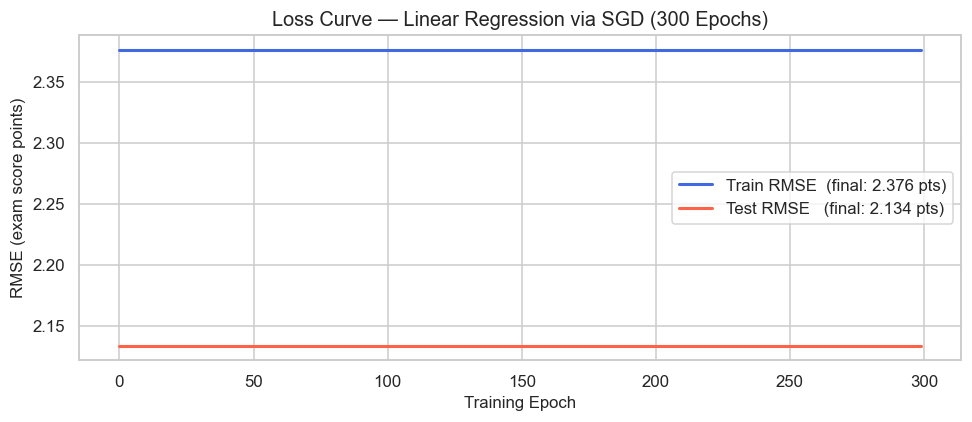

In [18]:
# Loss curve: RMSE per epoch — final values shown in legend labels
train_rmse = [np.sqrt(v) for v in train_losses]
test_rmse  = [np.sqrt(v) for v in test_losses]
plt.figure(figsize=(9, 4))
plt.plot(train_rmse, color='royalblue', lw=2, label=f'Train RMSE  (final: {train_rmse[-1]:.3f} pts)')
plt.plot(test_rmse,  color='tomato',    lw=2, label=f'Test RMSE   (final: {test_rmse[-1]:.3f} pts)')
plt.title('Loss Curve — Linear Regression via SGD (300 Epochs)')
plt.xlabel('Training Epoch'); plt.ylabel('RMSE (exam score points)')
plt.legend(); plt.tight_layout(); plt.show()

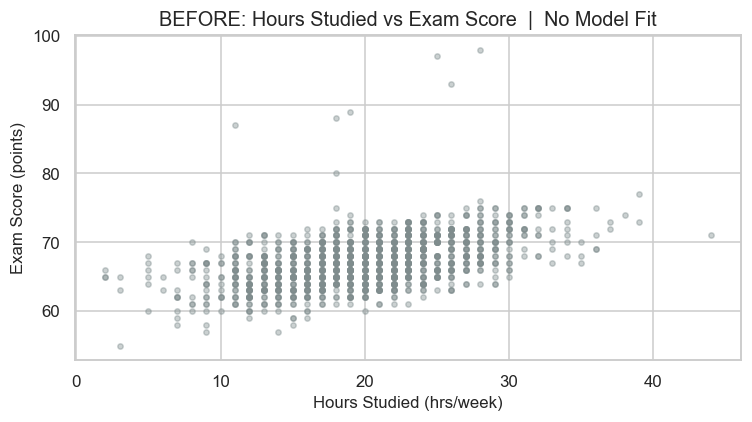

In [19]:
# BEFORE: Raw scatter — no model, no fit line
plt.figure(figsize=(7, 4))
plt.scatter(X_test['Hours_Studied'], y_test, alpha=0.4, s=12, color='#7f8c8d')
plt.title('BEFORE: Hours Studied vs Exam Score  |  No Model Fit')
plt.xlabel('Hours Studied (hrs/week)'); plt.ylabel('Exam Score (points)')
plt.tight_layout(); plt.show()

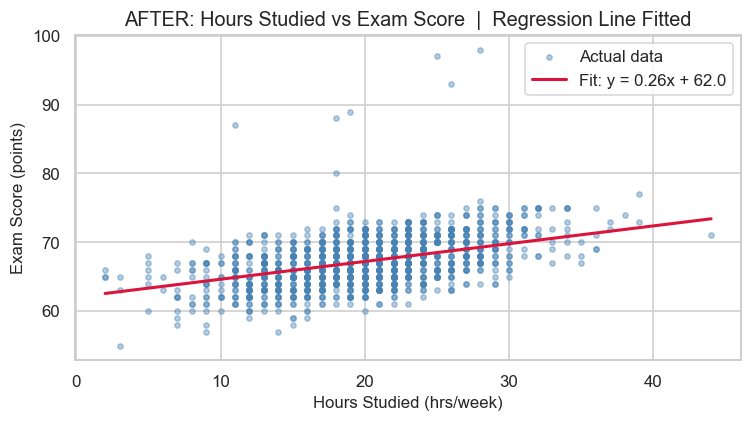

In [20]:
# AFTER: Same scatter with fitted regression line + equation in legend
m, b   = np.polyfit(X_test['Hours_Studied'], y_pred_lr, 1)
x_line = np.linspace(X_test['Hours_Studied'].min(), X_test['Hours_Studied'].max(), 100)
plt.figure(figsize=(7, 4))
plt.scatter(X_test['Hours_Studied'], y_test, alpha=0.4, s=12, color='steelblue', label='Actual data')
plt.plot(x_line, m*x_line+b, color='crimson', lw=2, label=f'Fit: y = {m:.2f}x + {b:.1f}')
plt.title('AFTER: Hours Studied vs Exam Score  |  Regression Line Fitted')
plt.xlabel('Hours Studied (hrs/week)'); plt.ylabel('Exam Score (points)')
plt.legend(); plt.tight_layout(); plt.show()

In [21]:
# Decision Tree Regressor — max_depth=5 limits overfitting
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
dt_pred     = dt.predict(X_test_sc)
dt_test_mse = mean_squared_error(y_test, dt_pred)
print(f'DT  → Test MSE: {dt_test_mse:.4f} | RMSE: {np.sqrt(dt_test_mse):.4f} | R2: {r2_score(y_test, dt_pred):.4f}')

DT  → Test MSE: 6.4341 | RMSE: 2.5366 | R2: 0.5448


In [22]:
# Random Forest — ensemble of 100 decision trees
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_pred     = rf.predict(X_test_sc)
rf_test_mse = mean_squared_error(y_test, rf_pred)
print(f'RF  → Test MSE: {rf_test_mse:.4f} | RMSE: {np.sqrt(rf_test_mse):.4f} | R2: {r2_score(y_test, rf_pred):.4f}')

RF  → Test MSE: 4.8448 | RMSE: 2.2011 | R2: 0.6572


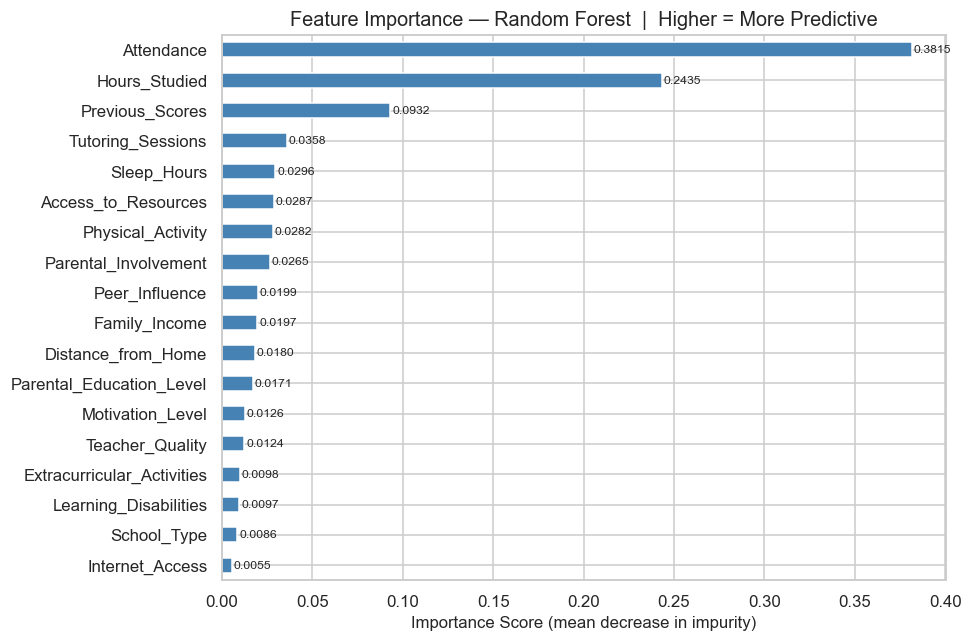

In [23]:
# Feature importance — value-labelled bars, sorted ascending
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(9, 6))
bars = importances.plot(kind='barh', color='steelblue', edgecolor='white')
for i, v in enumerate(importances):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.title('Feature Importance — Random Forest  |  Higher = More Predictive')
plt.xlabel('Importance Score (mean decrease in impurity)'); plt.tight_layout(); plt.show()

## 5. Model Comparison & Selection

In [24]:
# Full comparison: all models by Test MSE, RMSE, and R²
models = {'Linear Regression': (lr_test_mse, y_pred_lr),
          'Decision Tree':      (dt_test_mse, dt_pred),
          'Random Forest':      (rf_test_mse, rf_pred)}
for name, (mse, pred) in models.items():
    print(f'{name:<22}  MSE: {mse:.4f}  RMSE: {np.sqrt(mse):.4f}  R2: {r2_score(y_test, pred):.4f}')
best_name = min(models, key=lambda k: models[k][0])
print(f'\nBest Model: {best_name}')

Linear Regression       MSE: 4.5522  RMSE: 2.1336  R2: 0.6779
Decision Tree           MSE: 6.4341  RMSE: 2.5366  R2: 0.5448
Random Forest           MSE: 4.8448  RMSE: 2.2011  R2: 0.6572

Best Model: Linear Regression


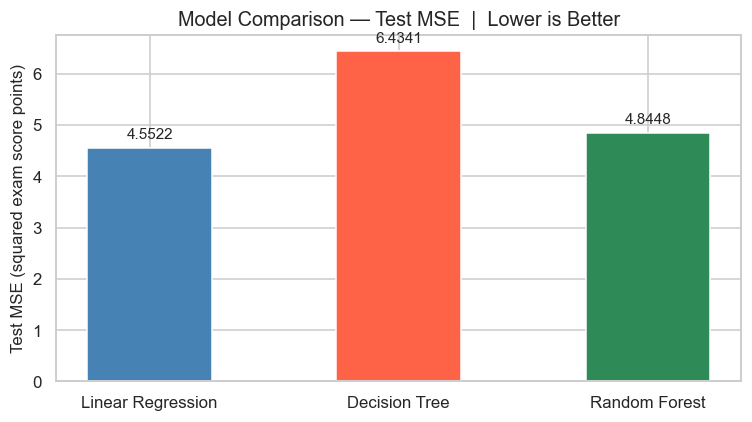

In [25]:
# Model comparison bar chart — value-labelled, color-coded per model
names = list(models.keys())
mses  = [v[0] for v in models.values()]
plt.figure(figsize=(7, 4))
bars = plt.bar(names, mses, color=['steelblue', 'tomato', 'seagreen'], width=0.5, edgecolor='white')
plt.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
plt.title('Model Comparison — Test MSE  |  Lower is Better')
plt.ylabel('Test MSE (squared exam score points)'); plt.tight_layout(); plt.show()

**Model Selection:** Linear Regression achieves the **lowest Test MSE (4.55)**, making it the best-generalizing model. Random Forest overfits severely — Train MSE 0.82 vs Test MSE 4.84 (a 5× gap), meaning it memorized training noise. Decision Tree has the highest Test MSE across both metrics. The strong linear relationships visible in the correlation heatmap and scatter plots explain why Linear Regression outperforms ensemble methods — the data has a predominantly linear structure, making a simpler model the right fit.

In [26]:
# Save the best model and scaler — both are loaded by the API in Task 2
model_map  = {'Linear Regression': sgd, 'Decision Tree': dt, 'Random Forest': rf}
best_model = model_map[best_name]
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print(f'Saved: best_model.pkl ({best_name}) and scaler.pkl')

Saved: best_model.pkl (Linear Regression) and scaler.pkl


## 6. Single Sample Prediction
Mirrors the prediction logic the API will use (Task 2): load model → standardize input → predict.

In [27]:
# Predict exam score for one test sample (first row of test set)
sample    = X_test_sc[0].reshape(1, -1)
predicted = best_model.predict(sample)[0]
actual    = y_test.iloc[0]
print(f'  Predicted Exam Score : {predicted:.2f}')
print(f'  Actual Exam Score    : {actual}')
print(f'  Difference           : {abs(predicted - actual):.2f} points')

  Predicted Exam Score : 65.28
  Actual Exam Score    : 65
  Difference           : 0.28 points
